# Step 2: Transformer-Based Temporal Randomness Verification

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
WINDOW_SIZE = 128  # 64 bytes per sequence
X, y = [], []

STEP = 16  # slide window by 8 bytes instead of 1
for i in range(0, len(byte_array) - WINDOW_SIZE, 3):
    X.append(byte_array[i:i+WINDOW_SIZE])
    y.append(byte_array[i+WINDOW_SIZE])

X = np.array(X)
y = np.array(y)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (3666624, 128)
Shape y: (3666624,)


In [ ]:
#first 80% for training, last 20% for validation
split_idx = int(0.8 * len(X))
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print("Train shape:", X_train.shape, X_val.shape)

Train shape: (2933299, 128) (733325, 128)


In [ ]:
from tensorflow.keras import layers, models

In [ ]:
EMBED_DIM = 8
NUM_HEADS = 2
FF_DIM = 16
DROPOUT_RATE = 0.2

def transformer_block(inputs, embed_dim, num_heads, ff_dim, rate=DROPOUT_RATE):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(inputs, inputs)
    attn_output = layers.Dropout(rate)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(inputs + attn_output)

    ffn_output = layers.Dense(ff_dim, activation='relu')(out1)
    ffn_output = layers.Dense(embed_dim)(ffn_output)
    ffn_output = layers.Dropout(rate)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

inputs = layers.Input(shape=(WINDOW_SIZE,))
x = layers.Embedding(input_dim=256, output_dim=EMBED_DIM)(inputs)
x = transformer_block(x, EMBED_DIM, NUM_HEADS, FF_DIM)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(256, activation='softmax')(x)  # 256 classes (0-255)

model = models.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 128, 8)    │      2,048 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 8)    │        568 │ embedding[0][0],  │
│ (MultiHeadAttentio… │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 8)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 8)    │          0 │ embedding[0][0],  │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 128, 8)    │         16 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128, 16)   │        144 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128, 8)    │        136 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128, 8)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 8)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 8)    │         16 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 8)         │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │        576 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     16,640 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,144 (78.69 KB)

 Trainable params: 20,144 (78.69 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=256,
    callbacks=[early_stop]
)

Epoch 1/5
11459/11459 ━━━━━━━━━━━━━━━━━━━━ 1096s 96ms/step - accuracy: 0.0039 - loss: 5.5454 - val_accuracy: 0.0039 - val_loss: 5.5455
Epoch 2/5
11459/11459 ━━━━━━━━━━━━━━━━━━━━ 1092s 95ms/step - accuracy: 0.0038 - loss: 5.5454 - val_accuracy: 0.0039 - val_loss: 5.5454
Epoch 3/5
11459/11459 ━━━━━━━━━━━━━━━━━━━━ 1100s 96ms/step - accuracy: 0.0039 - loss: 5.5454 - val_accuracy: 0.0039 - val_loss: 5.5454
Epoch 4/5
11459/11459 ━━━━━━━━━━━━━━━━━━━━ 1111s 97ms/step - accuracy: 0.0039 - loss: 5.5454 - val_accuracy: 0.0039 - val_loss: 5.5454
Epoch 5/5
11459/11459 ━━━━━━━━━━━━━━━━━━━━ 1103s 96ms/step - accuracy: 0.0039 - loss: 5.5454 - val_accuracy: 0.0038 - val_loss: 5.5454


18750/18750 ━━━━━━━━━━━━━━━━━━━━ 84s 4ms/step


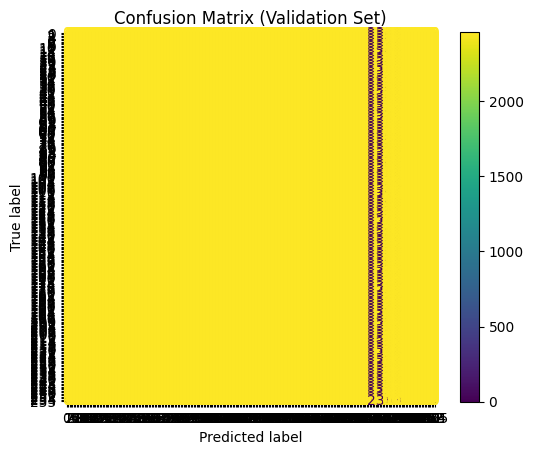

In [ ]:
#Confusion Matrix -- See which byte values (0–255) your model predicts well or confuses.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Get predictions on validation set
y_pred = np.argmax(model.predict(X_val), axis=1)

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='viridis', colorbar=True)
plt.title("Confusion Matrix (Validation Set)")
plt.show()

In [ ]:
# Compute testing/validation accuracy manually
# Predict classes for validation set
y_pred = np.argmax(model.predict(X_val), axis=1)

# Calculate accuracy
test_accuracy = np.mean(y_pred == y_val)

print(f"Testing Accuracy: {test_accuracy * 100:.4f}%")

22917/22917 ━━━━━━━━━━━━━━━━━━━━ 99s 4ms/step
Testing Accuracy: 0.3935%


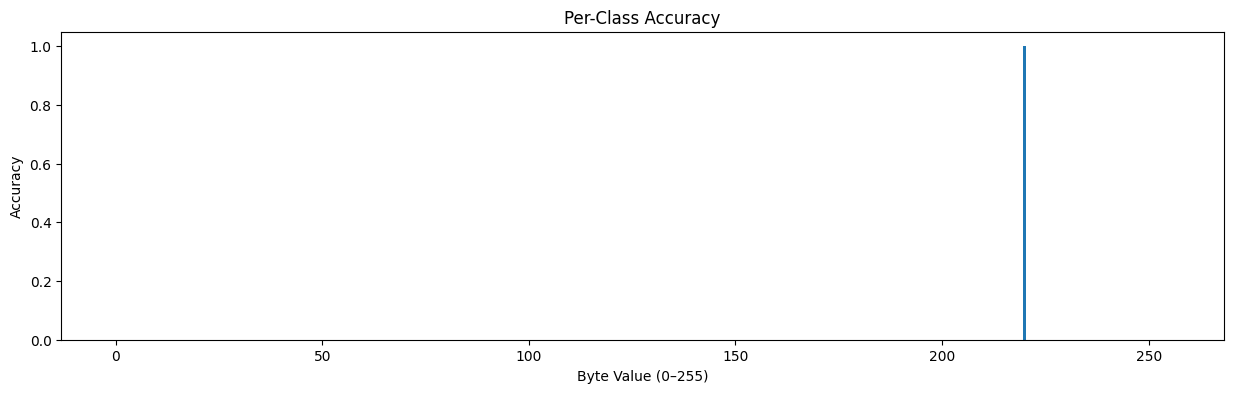

In [ ]:
#Per-Class Accuracy Plot
import pandas as pd

class_acc = []
for i in range(256):
    mask = (y_val == i)
    if np.any(mask):
        acc = np.mean(y_pred[mask] == y_val[mask])
        class_acc.append(acc)
    else:
        class_acc.append(np.nan)

plt.figure(figsize=(15, 4))
plt.bar(range(256), class_acc)
plt.xlabel('Byte Value (0–255)')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.show()

In [ ]:
#Predicted Probability Distribution

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


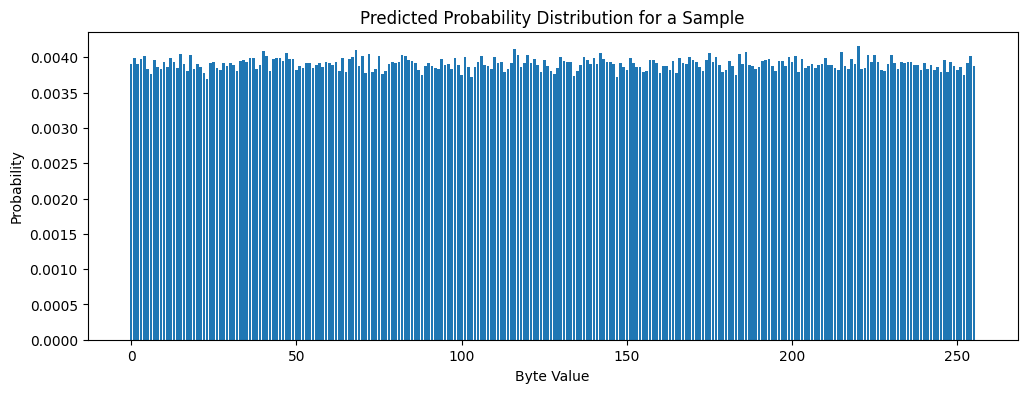

In [ ]:
probs = model.predict(X_val[:1])[0]  # first sample
plt.figure(figsize=(12, 4))
plt.bar(range(256), probs)
plt.title("Predicted Probability Distribution for a Sample")
plt.xlabel("Byte Value")
plt.ylabel("Probability")
plt.show()

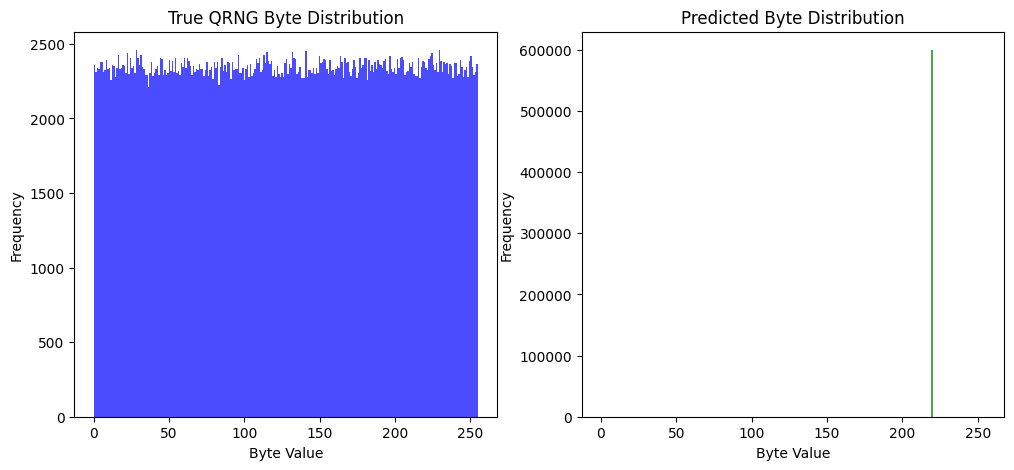

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(y_val, bins=256, range=(0, 255), color='blue', alpha=0.7)
plt.title("True QRNG Byte Distribution")
plt.xlabel("Byte Value")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(y_pred, bins=256, range=(0, 255), color='green', alpha=0.7)
plt.title("Predicted Byte Distribution")
plt.xlabel("Byte Value")
plt.ylabel("Frequency")

plt.show()

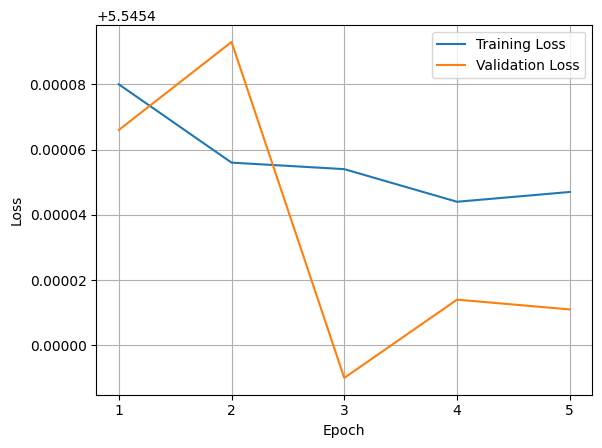

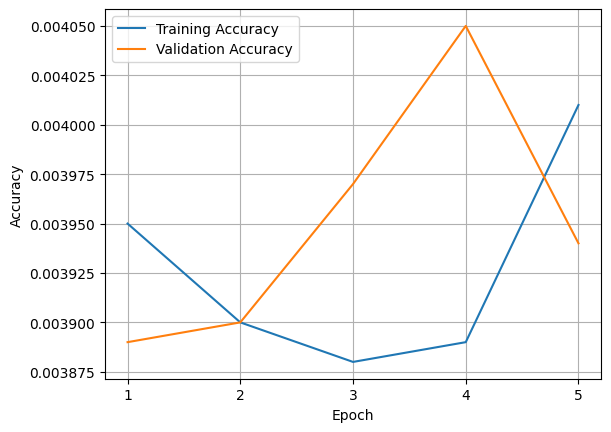

In [ ]:
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 6))

# Loss values
train_loss = [
    5.54548,  # Epoch 1
    5.545456, # Epoch 2
    5.545454, # Epoch 3
    5.545444, # Epoch 4
    5.545447  # Epoch 5
]

val_loss = [
    5.545466, # Epoch 1
    5.545493, # Epoch 2
    5.545390, # Epoch 3 (sharp dip)
    5.545414, # Epoch 4
    5.545411  # Epoch 5
]

# Accuracy values
train_acc = [0.00395, 0.00390, 0.00388, 0.00389, 0.00401]

val_acc = [0.00389, 0.00390, 0.00397, 0.00405, 0.00394]

# -------- Plot 1: Training vs Validation Loss --------
plt.figure()
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.grid(True)
plt.legend()
# plt.title('Training and Validation Loss')
plt.show()

# -------- Plot 2: Training vs Validation Accuracy --------
plt.figure()
plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs)
plt.grid(True)
plt.legend()
# plt.title('Training and Validation Accuracy')
plt.show()